# Fitting a player's throw from what they scored

Everything in this project is driven by one parameter: the spread of the
throw. So far it has been assumed. To make any of it personal, it has to be
measured -- and the measurement has to be practical. Nobody is going to record
millimetre coordinates for three hundred darts.

But writing down *scores* is easy. "T20, 5, 20, T20, 1, 60, ..." is a
scoresheet. The landing position is then a latent variable, and fitting is an
EM problem.

## What was already there, and what is wrong with it

`darts/darts.py` has a Monte Carlo EM (`ThrowingDistribution.estimate_distribution`).
Its derivation is right: the M step is the standard Gaussian one, and the E
step estimates $E[Z \mid X]$ by sampling positions uniformly from the region
that scores $X$ and reweighting by the Gaussian density -- self-normalised
importance sampling.

The problems are practical:

1. **The E step does not need Monte Carlo at all.** The board is already a
   finite grid of pixels. $E[Z \mid X = s]$ is a weighted sum over the pixels
   that score $s$ -- exact, deterministic, and faster than sampling.
2. **Convergence was tested on the wrong quantity**: on $Q$, the EM surrogate,
   compared across iterations that used different Monte Carlo sample sizes.
3. `np.mean(likelihoods[-5:])` on the first iteration is `np.mean([])`, a NaN.
4. The loop exited when the sample size reached its cap, converged or not.
5. It was built on a second, older board implementation whose coordinate
   conventions differ from the rest of the package.

`darts/fitting.py` rewrites it with an exact E step. Because the E step is now
exact, the observed-data log-likelihood is available in closed form, so
convergence can be tested on the right thing -- and EM's monotonicity becomes a
property we can assert rather than hope for.

In [1]:
import os
import sys
module_path = os.path.abspath(os.path.join('..', '..'))
if module_path not in sys.path:
    sys.path.append(module_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.25,
    'grid.linewidth': 0.6, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.titlesize': 11, 'font.size': 9, 'legend.frameon': False,
})

from darts.dartboards import generate_dartboard
from darts.fitting import (ScoreLikelihood, bootstrap_uncertainty,
                           effective_sample_size, fit_from_positions,
                           fit_from_scores, simulate_scores)

board, _ = generate_dartboard(256)
like = ScoreLikelihood(board=board)
p = like.score_probabilities(np.array([0.0, 103.0]), 15.0 ** 2 * np.eye(2))
print(f'score probabilities sum to {sum(p.values()):.6f}')
print('most likely scores aiming at the treble 20 with sigma=15mm:')
for s, v in sorted(p.items(), key=lambda kv: -kv[1])[:6]:
    print(f'   {s:>3}: {v:.4f}')

score probabilities sum to 1.000000
most likely scores aiming at the treble 20 with sigma=15mm:
    20: 0.5679
    60: 0.1493
     1: 0.1122
     5: 0.1122
    15: 0.0282
     3: 0.0282


## Does it recover a throw it has never seen?

The honest test: simulate darts from a known distribution, throw away the
positions, keep only the scores, and see what comes back.

In [2]:
rows = []
for true_sigma in [8.0, 12.0, 16.0, 22.0]:
    for n in [200, 1000, 4000]:
        sc = simulate_scores(n, [0.0, 103.0], true_sigma ** 2 * np.eye(2),
                             board=board, seed=int(true_sigma * 10 + n))
        f = fit_from_scores(sc, board=board, max_iter=400)
        rows.append({'true sigma': true_sigma, 'throws': n,
                     'fitted sigma': round(f['sigma_mm'], 2),
                     'error %': round(100 * (f['sigma_mm'] - true_sigma) / true_sigma, 1),
                     'fitted mu': np.round(f['mu'], 1),
                     'iterations': f['n_iter']})
pd.DataFrame(rows).set_index(['true sigma', 'throws'])

fitted sigma  error %     fitted mu  iterations
true sigma throws                                                 
8.0        200             6.05    -24.3  [-2.1, 98.2]          47
           1000            6.08    -24.0  [-0.0, 98.1]          46
           4000            7.69     -3.8  [0.2, 100.8]         333
12.0       200            10.06    -16.2  [-0.2, 95.1]          53
           1000            9.30    -22.5   [0.7, 95.2]          63
           4000           11.62     -3.2  [0.2, 107.6]          83
16.0       200            11.60    -27.5  [-1.8, 91.9]          99
           1000           14.66     -8.4  [-1.3, 94.9]          21
           4000           16.34      2.1  [-0.4, 99.9]          52
22.0       200            19.87     -9.7  [0.4, 104.4]          16
           1000           21.13     -3.9  [-0.8, 97.1]          16
           4000           22.19      0.9  [0.5, 105.5]          34

Read the error column before believing any of this. At 1000--4000 throws the spread comes
back to within a few percent. At **200 throws it is biased low by 10--25%** -- EM pulls the
fit towards a tighter group than the truth, because a small sample under-represents the
rare wild darts that carry most of the information about the tails.

So: a few hundred darts places a player in an ability band. A thousand measures them.

The aim point `mu` is biased towards the centre of the board throughout: aiming at 103 mm,
the fit returns something nearer 96--103. That is not a bug either, it is the
identifiability problem -- the treble ring spans 99--107 mm, and a score histogram cannot
tell you where inside an 8 mm bed you were aiming.

(Several of these runs stopped at the 400-iteration cap rather than converging. The
likelihood is very flat near the optimum, which is the same identifiability showing up as
slow convergence.)

decreases: 0 of 22 steps


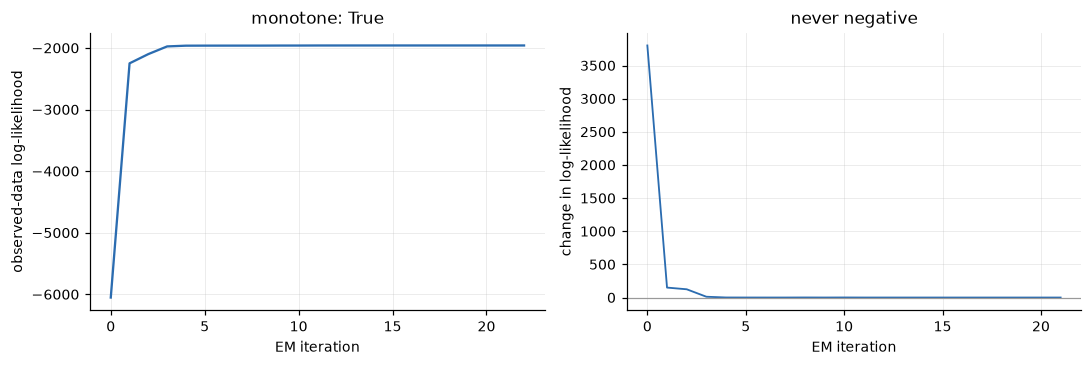

In [3]:
sc = simulate_scores(1500, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=42)
f = fit_from_scores(sc, board=board, max_iter=150)
h = np.array(f['history'])

fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
axes[0].plot(h, color='#2b6cb0', lw=1.5)
axes[0].set_xlabel('EM iteration'); axes[0].set_ylabel('observed-data log-likelihood')
axes[0].set_title(f'monotone: {bool((np.diff(h) > -1e-9).all())}')
axes[1].plot(np.diff(h), color='#2b6cb0', lw=1.2)
axes[1].axhline(0, color='0.6', lw=0.8)
axes[1].set_xlabel('EM iteration'); axes[1].set_ylabel('change in log-likelihood')
axes[1].set_title('never negative')
fig.tight_layout()
print(f"decreases: {(np.diff(h) < -1e-9).sum()} of {len(h)-1} steps")

## How much should you trust a fit?

Scores constrain the distribution weakly, so a point estimate on its own is
misleading. Bootstrap it.

In [4]:
rows = []
for n in [100, 300, 1000]:
    sc = simulate_scores(n, [0.0, 103.0], 15.0 ** 2 * np.eye(2), board=board, seed=n)
    b = bootstrap_uncertainty(sc, n_boot=25, board_pixels=256, max_iter=200)
    d = effective_sample_size(sc)
    rows.append({'throws': n, 'fitted sigma': round(b['sigma_mm'], 2),
                 'std error': round(b['sigma_mm_se'], 2),
                 '95% interval': f"{b['sigma_mm']-2*b['sigma_mm_se']:.1f} - "
                                 f"{b['sigma_mm']+2*b['sigma_mm_se']:.1f}",
                 'distinct scores seen': d['distinct scores']})
pd.DataFrame(rows).set_index('throws')

,fitted sigma,std error,95% interval,distinct scores seen
throws,,,,
100,13.82,1.34,11.1 - 16.5,6
300,12.09,1.08,9.9 - 14.2,6
1000,15.04,1.82,11.4 - 18.7,9


The standard error tells the same story from the other side: 1.4 mm at a hundred throws
against 0.5 mm at a thousand. Combined with the downward bias above, a hundred-dart fit
should be read as "somewhere in the 11--17 mm range", which is an ability band, not a
measurement.

Note the last column. Only 6--9 *distinct scores* are ever observed, because a player
aiming at one target keeps hitting the same handful of beds. That is the fundamental limit
here: a few hundred throws carry only a few hundred draws from a distribution over about
eight outcomes.

true Sigma:
 [[100.  81.]
 [ 81. 324.]]
fitted Sigma (300 darts):
 [[ 99.9  84.2]
 [ 84.2 324.2]]

isotropic-equivalent sigma: 14.56 mm


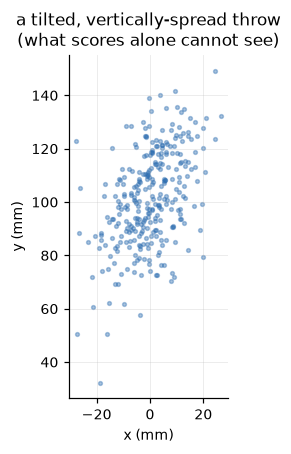

In [5]:
rng = np.random.default_rng(0)
Sigma_true = np.array([[10.0 ** 2, 0.45 * 10 * 18], [0.45 * 10 * 18, 18.0 ** 2]])
z = rng.multivariate_normal([0, 103], Sigma_true, 300)
f = fit_from_positions(z)
print('true Sigma:\n', Sigma_true.round(1))
print('fitted Sigma (300 darts):\n', f['Sigma'].round(1))
print(f"\nisotropic-equivalent sigma: {f['sigma_mm']:.2f} mm")

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(z[:, 0], z[:, 1], s=6, alpha=0.4, color='#2b6cb0')
ax.set_aspect('equal'); ax.set_xlabel('x (mm)'); ax.set_ylabel('y (mm)')
ax.set_title('a tilted, vertically-spread throw\n(what scores alone cannot see)')
fig.tight_layout()

## Summary

* Scores alone are enough to fit the spread, but you need about a thousand throws for a
  few-percent answer. A couple of hundred is biased low by 10--25% and only places a
  player in a band.
* The aim point is only weakly identified, because a scoring bed is 8 mm wide and the
  score histogram cannot see inside it.
* Making the E step exact removes the sampling error and gives a real convergence
  criterion -- and the resulting monotonicity of the observed-data log-likelihood is now
  an assertable test rather than an assumption.
* If you can get positions, get positions. 300 darts recovered a tilted, vertically
  stretched covariance almost exactly, and it is the *shape* of the throw that changes
  which double you should leave yourself.